In [12]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import random
import math



In [13]:
##Golden Solution
x, y = sp.symbols('x y')

f = sp.exp(x**2 + y**2) - 4*x

# Partielle Ableitungen
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)
print("df/dx =", df_dx)
print("df/dy =", df_dy)

# Gleichungssystem lösen
optimum = sp.solve([df_dx, df_dy], [x, y])
print("Optimum bei:", optimum)





df/dx = 2*x*exp(x**2 + y**2) - 4
df/dy = 2*y*exp(x**2 + y**2)
Optimum bei: [(2*exp(-LambertW(8)/2), 0)]


In [14]:
# Newton Methode braucht Ableitungen/ Gradient und Hesse
# Ableitungen
f_dx = sp.diff(f, x)
f_dy = sp.diff(f, y)
f_dxx = sp.diff(f_dx, x)
f_dyy = sp.diff(f_dy, y)
f_dxy = sp.diff(f_dx, y)

print("f(x,y) =", f)
print("∂f/∂x =", f_dx)
print("∂f/∂y =", f_dy)

# Hessian Matrix
H = sp.Matrix([
    [f_dxx, f_dxy],
    [f_dxy, f_dyy]
])

# Gradient
grad = sp.Matrix([f_dx, f_dy])

# Newton Methode
x_n = sp.Matrix([sp.Float(2.0), sp.Float(2.0)]) 
path = [x_n.T.tolist()[0]]

for i in range(100):
    grad_val = grad.subs([(x, x_n[0]), (y, x_n[1])])
    H_val = H.subs([(x, x_n[0]), (y, x_n[1])])
    
    x_n = x_n - H_val.inv() * grad_val
    path.append(x_n.T.tolist()[0])
    
    f_val = f.subs([(x, x_n[0]), (y, x_n[1])])
    print(f"Iteration {i+1}: x = {float(x_n[0]):.6f}, y = {float(x_n[1]):.6f}, f = {float(f_val):.6f}")

print(f"\nOptimum bei x = {float(x_n[0]):.4f}, y = {float(x_n[1]):.4f}")

#KOnstante Hesse -> Optimum wird sofort gefunden bei quadratischen Funktionen
print("\nHessian =", H)


f(x,y) = -4*x + exp(x**2 + y**2)
∂f/∂x = 2*x*exp(x**2 + y**2) - 4
∂f/∂y = 2*y*exp(x**2 + y**2)
Iteration 1: x = 1.882708, y = 1.882037, f = 1188.368780
Iteration 2: x = 1.759519, y = 1.757220, f = 477.758382
Iteration 3: x = 1.630106, y = 1.623857, f = 192.649253
Iteration 4: x = 1.494875, y = 1.479140, f = 77.325324
Iteration 5: x = 1.356143, y = 1.318113, f = 30.325333
Iteration 6: x = 1.220514, y = 1.131912, f = 11.090595
Iteration 7: x = 1.102129, y = 0.905997, f = 3.247700
Iteration 8: x = 1.020871, y = 0.624461, f = 0.104123
Iteration 9: x = 0.976674, y = 0.305281, f = -1.057353
Iteration 10: x = 0.930159, y = 0.071342, f = -1.333044
Iteration 11: x = 0.899520, y = 0.004744, f = -1.352062
Iteration 12: x = 0.896077, y = 0.000030, f = -1.352183
Iteration 13: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 14: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 15: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 16: x = 0.896050, y = 0.000000, f = -1.352183
Iteration 17: x 

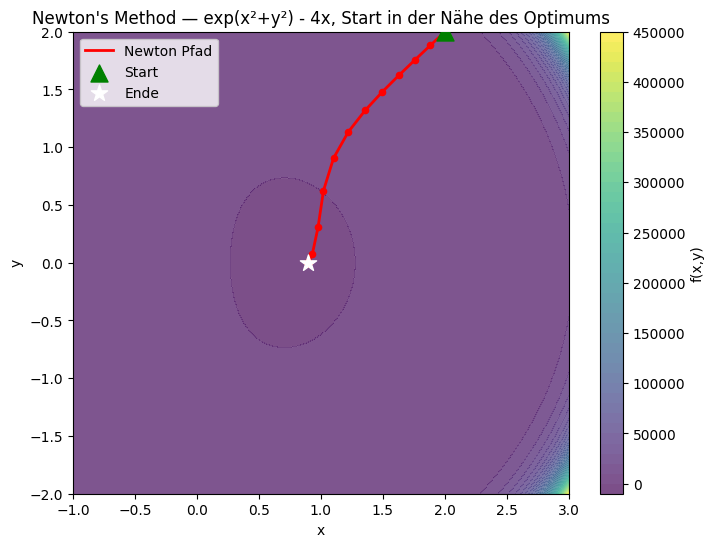

In [15]:
# Path in numpy arrays umwandeln
path_np = np.array([(float(p[0]), float(p[1])) for p in path])

#Konturplot der Funktion
x_grid = np.linspace(-1, 3, 300)
y_grid = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x_grid, y_grid)

Z = np.exp(X**2 + Y**2) - 4*X

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(label='f(x,y)')
plt.contour(X, Y, Z, levels=50, colors='white', linewidths=0.3, alpha=0.4)

# Pfad plotten
plt.plot(path_np[:, 0], path_np[:, 1], color='red', lw=2, label='Newton Pfad')
plt.scatter(path_np[:, 0], path_np[:, 1], color='red', s=20, zorder=5)
plt.scatter(path_np[0, 0], path_np[0, 1], color='green', s=150, marker='^', zorder=6, label='Start')
plt.scatter(path_np[-1, 0], path_np[-1, 1], color='white', s=150, marker='*', zorder=6, label='Ende')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Newton's Method — exp(x²+y²) - 4x, Start in der Nähe des Optimums")
plt.legend()
plt.show()


##Line Search ist wichtig

In [19]:
#Simulated Annealing
x_curr = random.uniform(-2, 2)
y_curr = random.uniform(-2, 2)

# Funktionswert am Startpunkt
f_curr = float(f.subs({x: x_curr, y: y_curr}))

# Bisher beste Lösung
x_best = x_curr
y_best = y_curr
f_best = f_curr

# Simulated Annealing Parameter
T = 10.0           # Anfangstemperatur
T_min = 1e-6       # Abbruchtemperatur
alpha = 0.995      # Abkühlrate
n_iter = 200     # maximale Iterationen
step_size = 0.15   # Schrittweite für neue Kandidaten

for i in range(n_iter):
    if T < T_min:
        break

    # Neuen Kandidaten in der Nachbarschaft erzeugen
    x_new = x_curr + random.uniform(-step_size, step_size)
    y_new = y_curr + random.uniform(-step_size, step_size)

    # Funktionswert am neuen Punkt
    f_new = float(f.subs({x: x_new, y: y_new}))

    # Differenz
    delta = f_new - f_curr

    # Akzeptanzregel
    if delta < 0:
        # Verbesserung -> immer annehmen
        x_curr = x_new
        y_curr = y_new
        f_curr = f_new
    else:
        # Verschlechterung evtl. trotzdem annehmen
        p = math.exp(-delta / T)
        if random.random() < p:
            x_curr = x_new
            y_curr = y_new
            f_curr = f_new

    # Beste Lösung aktualisieren
    if f_curr < f_best:
        x_best = x_curr
        y_best = y_curr
        f_best = f_curr

    # Temperatur senken
    T *= alpha

print("Beste gefundene Lösung:")
print("x =", x_best)
print("y =", y_best)
print("f(x,y) =", f_best)

Beste gefundene Lösung:
x = 0.6171526071131801
y = -0.35072335675797134
f(x,y) = -0.8134727190890125


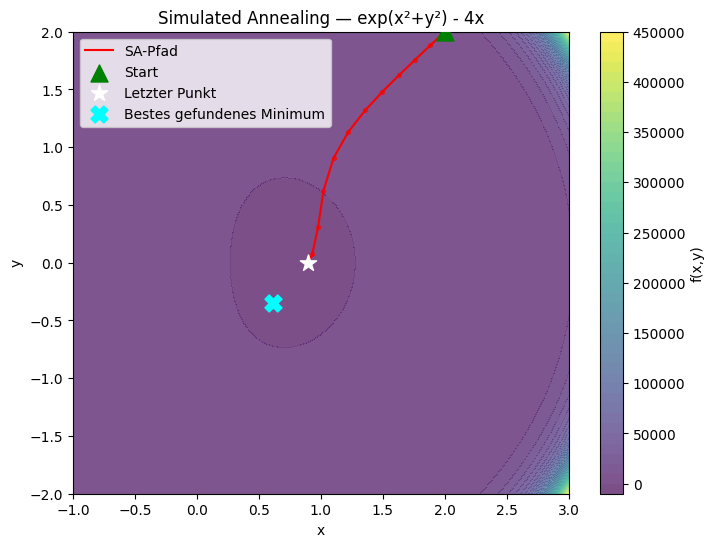

In [20]:

# In numpy-Array umwandeln
path_np = np.array(path)

# ----------------------------
# Konturplot der Funktion
# ----------------------------
x_grid = np.linspace(-1, 3, 300)
y_grid = np.linspace(-2, 2, 300)
X, Y = np.meshgrid(x_grid, y_grid)

Z = np.exp(X**2 + Y**2) - 4*X

plt.figure(figsize=(8, 6))
plt.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(label='f(x,y)')
plt.contour(X, Y, Z, levels=50, colors='white', linewidths=0.3, alpha=0.4)

# Pfad des Simulated Annealing plotten
plt.plot(path_np[:, 0], path_np[:, 1], color='red', lw=1.5, label='SA-Pfad')
plt.scatter(path_np[:, 0], path_np[:, 1], color='red', s=8, alpha=0.6, zorder=5)

# Startpunkt
plt.scatter(path_np[0, 0], path_np[0, 1],
            color='green', s=150, marker='^', zorder=6, label='Start')

# Letzter Punkt
plt.scatter(path_np[-1, 0], path_np[-1, 1],
            color='white', s=150, marker='*', zorder=6, label='Letzter Punkt')

# Bester gefundener Punkt
plt.scatter(x_best, y_best,
            color='cyan', s=150, marker='X', zorder=7, label='Bestes gefundenes Minimum')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Simulated Annealing — exp(x²+y²) - 4x")
plt.legend()
plt.show()

# Mehr Iterationen notwendig oder Optimizer einbauen damit 

In [7]:
# Pfad, Anzahl Dimensionen und Wahres Optimum ? 
class Visualizer:
    def __init__(self, f, bounds):
        self.f = f
        self.bounds = bounds
        self.ndim = len(bounds)
    
    def plot(self, runs):
        """
        runs: Liste von Tupeln (path, values, label)
        path:   np.array shape (n_steps, ndim)
        values: np.array shape (n_steps,)
        label:  string z.B. "Newton"
        """
        if self.ndim == 1:
            self._plot_1d(runs)
        elif self.ndim == 2:
            self._plot_2d(runs)
        else:
            self._plot_pairplot(runs)
    
    def _plot_1d(self, runs):
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        ax_f, ax_conv = axes
    
    # Funktion plotten
        lo, hi = self.bounds[0]
        xs = np.linspace(lo, hi, 300)
        ys = [self.f(np.array([x])) for x in xs]
        ax_f.plot(xs, ys, color='gray', lw=2, label='f(x)')
        ax_f.set_xlabel('x')
        ax_f.set_ylabel('f(x)')
        ax_f.set_title('Funktion & Pfad')
    
    # Pfade plotten
        colors = ['red', 'blue', 'green', 'orange']
        for i, (path, values, label) in enumerate(runs):
            color = colors[i % len(colors)]
            px = path[:, 0]
            ax_f.scatter(px, values, color=color, s=30, zorder=3)
            ax_f.plot(px, values, color=color, lw=1, alpha=0.5)
            ax_f.scatter(px[0], values[0], color=color, s=100, marker='^', zorder=4, label=f'{label} Start')
            ax_f.scatter(px[-1], values[-1], color=color, s=100, marker='*', zorder=4, label=f'{label} Ende')
        
        # Konvergenzkurve
            ax_conv.plot(values, color=color, lw=2, label=label)
    
        ax_f.legend()
        ax_conv.set_xlabel('Iteration')
        ax_conv.set_ylabel('f(x)')
        ax_conv.set_title('Konvergenz')
        ax_conv.legend()
        plt.tight_layout()
        plt.show()
        
    def _plot_2d(self, runs):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax_contour, ax_conv = axes
    
        # Konturplot erstellen
        lo0, hi0 = self.bounds[0]
        lo1, hi1 = self.bounds[1]
        xs = np.linspace(lo0, hi0, 300)
        ys = np.linspace(lo1, hi1, 300)
        X, Y = np.meshgrid(xs, ys)
        Z = np.vectorize(lambda u, v: self.f(np.array([u, v])))(X, Y)
    
        ax_contour.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.7)
        ax_contour.contour(X, Y, Z, levels=50, colors='white', linewidths=0.3, alpha=0.4)
        ax_contour.set_xlabel('x0')
        ax_contour.set_ylabel('x1')
        ax_contour.set_title('Konturplot & Pfad')
    
    # Pfade plotten
        colors = ['red', 'blue', 'green', 'orange']
        for i, (path, values, label) in enumerate(runs):
            color = colors[i % len(colors)]
            px = path[:, 0]
            py = path[:, 1]
            ax_contour.plot(px, py, color=color, lw=1.5, alpha=0.8)
            ax_contour.scatter(px, py, color=color, s=15, alpha=0.6)
            ax_contour.scatter(px[0], py[0], color=color, s=120, marker='^', zorder=5, label=f'{label} Start')
            ax_contour.scatter(px[-1], py[-1], color=color, s=150, marker='*', zorder=5, label=f'{label} Ende')
        
            # Konvergenzkurve
            ax_conv.plot(values, color=color, lw=2, label=label)
    
        ax_contour.legend()
        ax_conv.set_xlabel('Iteration')
        ax_conv.set_ylabel('f(x)')
        ax_conv.set_title('Konvergenz')
        ax_conv.legend()
        plt.tight_layout()
        plt.show()   
        


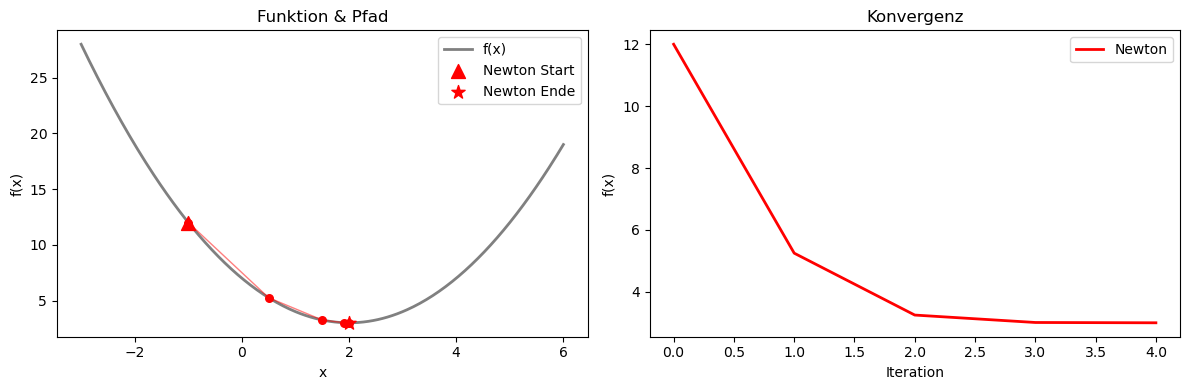

In [5]:
f = lambda x: (x[0] - 2)**2 + 3

# Simulierter Newton Pfad
path = np.array([[-1.0], [0.5], [1.5], [1.9], [2.0]])
values = np.array([f(p) for p in path])

viz = Visualizer(f=f, bounds=[(-3, 6)])
viz.plot([(path, values, "Newton")])

In [ ]:
import sympy as sp

x, y = sp.symbols('x y')
f_sym = sp.exp(x**2 + y**2) - 4*x
f_np = lambda p: float(f_sym.subs([(x, p[0]), (y, p[1])]))


viz = Visualizer(f=f_np, bounds=[(-2, 3), (-2, 2)])
viz.plot([(path, np.array([f_np(p) for p in path]), "Newton")])

In [15]:
print(path)

[[2.00000000000000, 2.00000000000000], [1.88270813690013, 1.88203721164433], [1.75951888940858, 1.75722007889117], [1.63010639041890, 1.62385660446771], [1.49487475937381, 1.47914025842934], [1.35614324776617, 1.31811347151214], [1.22051358774690, 1.13191183635194], [1.10212870723759, 0.905996688522381], [1.02087129081852, 0.624460998111824], [0.976673873047046, 0.305280812741189], [0.930158940103359, 0.0713422225989308], [0.899520074430566, 0.00474429475991135], [0.896076956483466, 2.95998600968427e-5], [0.896050222213447, 1.41823819055614e-9], [0.896050220780113, 3.64299771627336e-18], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0], [0.896050220780113, 0

OptimizationResult(GradientDescent | konvergiert | Minimum: f([2.35391315e-06 3.13855087e-06]) = 0.000000 | 63 Iterationen)
Pfad: [[3.00000000e+00 4.00000000e+00]
 [2.40000000e+00 3.20000000e+00]
 [1.92000000e+00 2.56000000e+00]
 [1.53600000e+00 2.04800000e+00]
 [1.22880000e+00 1.63840000e+00]
 [9.83040000e-01 1.31072000e+00]
 [7.86432000e-01 1.04857600e+00]
 [6.29145600e-01 8.38860800e-01]
 [5.03316480e-01 6.71088640e-01]
 [4.02653184e-01 5.36870912e-01]
 [3.22122547e-01 4.29496730e-01]
 [2.57698038e-01 3.43597384e-01]
 [2.06158430e-01 2.74877907e-01]
 [1.64926744e-01 2.19902326e-01]
 [1.31941395e-01 1.75921860e-01]
 [1.05553116e-01 1.40737488e-01]
 [8.44424930e-02 1.12589991e-01]
 [6.75539944e-02 9.00719925e-02]
 [5.40431955e-02 7.20575940e-02]
 [4.32345564e-02 5.76460752e-02]
 [3.45876451e-02 4.61168602e-02]
 [2.76701161e-02 3.68934881e-02]
 [2.21360929e-02 2.95147905e-02]
 [1.77088743e-02 2.36118324e-02]
 [1.41670994e-02 1.88894659e-02]
 [1.13336796e-02 1.51115727e-02]
 [9.06694365

OptimizationResult(Newton | konvergiert | Minimum: f([-2.]) = 0.000000 | 2 Iterationen)


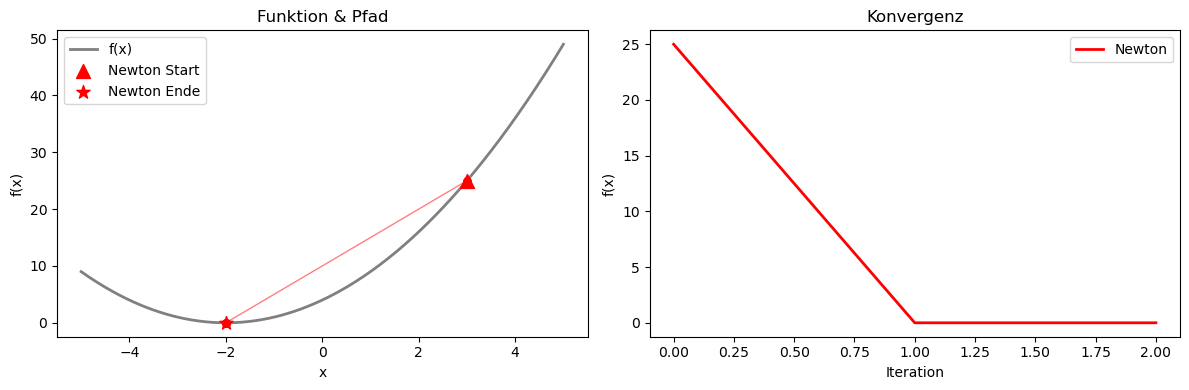

In [7]:
import numpy as np
from base import BaseOptimizer, OptimizationResult
from newton import Newton
from class_Visualizer import Visualizer

def rosenbrock(x):
   # return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
    return((x[0]+2)**2)



opt = Newton(rosenbrock, bounds= [(-5, 5)])
result = opt.run(x0=[3])

print(result)

viz = Visualizer(f=rosenbrock, bounds=[(-5,5)])
viz.plot([(result.path, result.f_path, "Newton")])

In [3]:
import numpy as np

def nelder_mead(f, x0, tol=1e-6, max_iter=1000, step_size=0.5):
    x0 = np.array(x0, dtype=float)
    n = len(x0)

    # Simplex initialisieren
    simplex = [x0.copy()]
    for i in range(n):
        punkt = x0.copy()
        punkt[i] += step_size
        simplex.append(punkt)
    simplex = np.array(simplex)

    path = [x0.copy()]
    f_path = [f(x0)]

    for iteration in range(max_iter):
        werte = np.array([f(p) for p in simplex])
        reihenfolge = np.argsort(werte)
        simplex = simplex[reihenfolge]
        werte = werte[reihenfolge]

        bester = simplex[0]
        schlechtester = simplex[-1]
        schwerpunkt = np.mean(simplex[:-1], axis=0)

        path.append(bester.copy())
        f_path.append(werte[0])

        if np.max(np.abs(simplex - bester)) < tol:
            break

        reflexion = schwerpunkt + 1.0 * (schwerpunkt - schlechtester)
        f_reflexion = f(reflexion)

        if f_reflexion < werte[0]:
            expansion = schwerpunkt + 2.0 * (reflexion - schwerpunkt)
            if f(expansion) < f_reflexion:
                simplex[-1] = expansion
            else:
                simplex[-1] = reflexion
        elif f_reflexion < werte[-2]:
            simplex[-1] = reflexion
        else:
            kontraktion = schwerpunkt + 0.5 * (schlechtester - schwerpunkt)
            if f(kontraktion) < werte[-1]:
                simplex[-1] = kontraktion
            else:
                for i in range(1, len(simplex)):
                    simplex[i] = bester + 0.5 * (simplex[i] - bester)

    return np.array(path), np.array(f_path)



path, f_path = nelder_mead(lambda x: x[0]**2 + x[1]**2, x0=[3, 4])
print("Minimum bei:", path[-1])
print("f(Minimum):", f_path[-1])

Minimum bei: [-3.72858311e-07  2.41229885e-07]
f(Minimum): 1.9721517762176383e-13


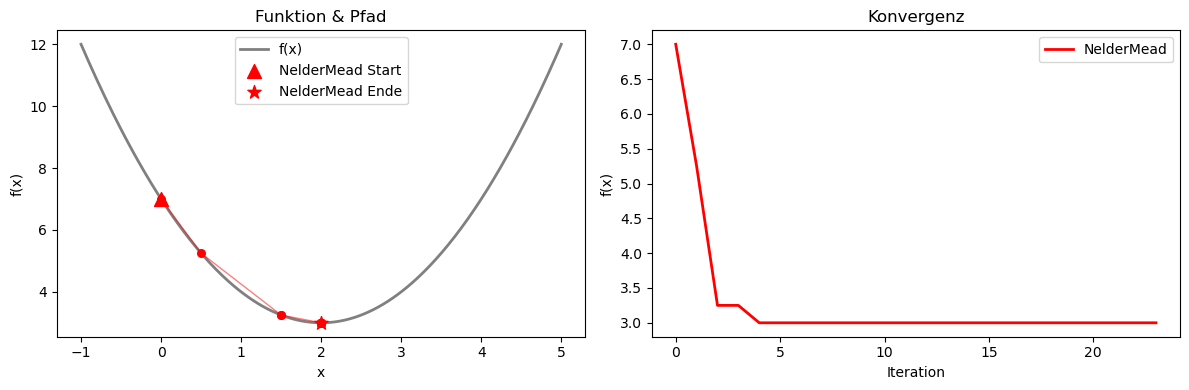

[[0. ]
 [0.5]
 [1.5]
 [1.5]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]
 [2. ]]
[7.   5.25 3.25 3.25 3.   3.   3.   3.   3.   3.   3.   3.   3.   3.
 3.   3.   3.   3.   3.   3.   3.   3.   3.   3.  ]


In [5]:
import numpy as np
from base import BaseOptimizer, OptimizationResult
from newton import Newton
from neldermead import NelderMead
from class_Visualizer import Visualizer

def parabel(x):
    return (x[0] - 2)**2 + 3

bounds_1d = [(-1, 5)]
result = NelderMead(parabel, bounds=bounds_1d).run(x0=[0])
viz = Visualizer(f=parabel, bounds=bounds_1d)
viz.plot([(result.path, result.f_path, "NelderMead")])

print(result.path)
print(result.f_path)

In [1]:
import optiviz

def rosenbrock(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

bounds = [(-5, 5), (-5, 5)]

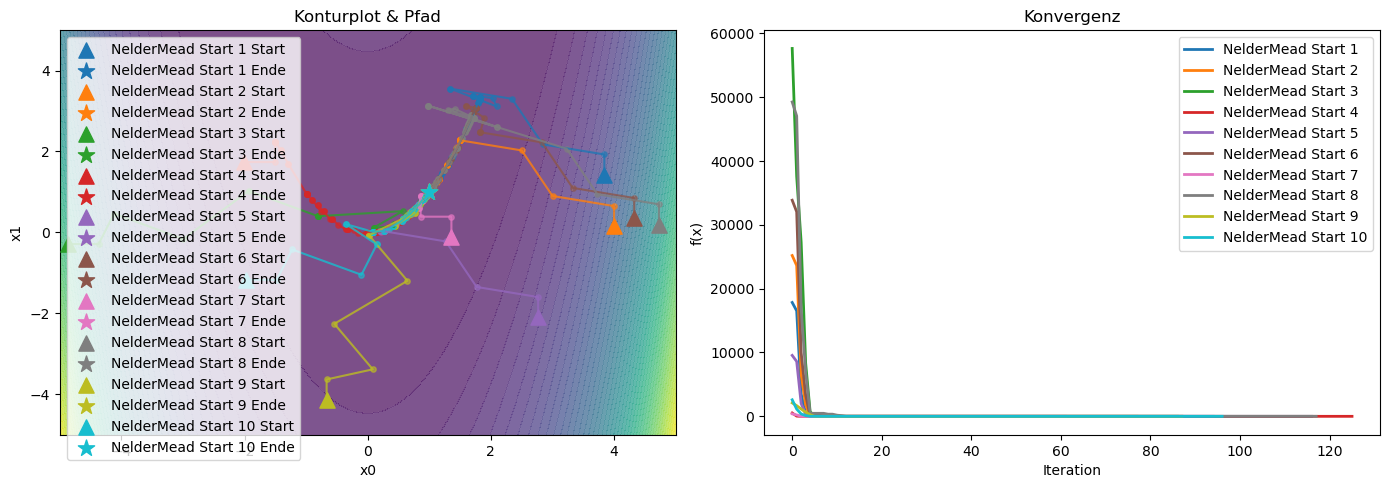

In [7]:
results = optiviz.optimize(rosenbrock, bounds, method="neldermead",
                           multistart=True, n_starts=10)
results.plot()

In [6]:
print(results)

OptimizeResult(neldermead | 10 Lauf/Läufe | bestes Minimum: f([1.00000009 1.00000018]) = 0.000000)


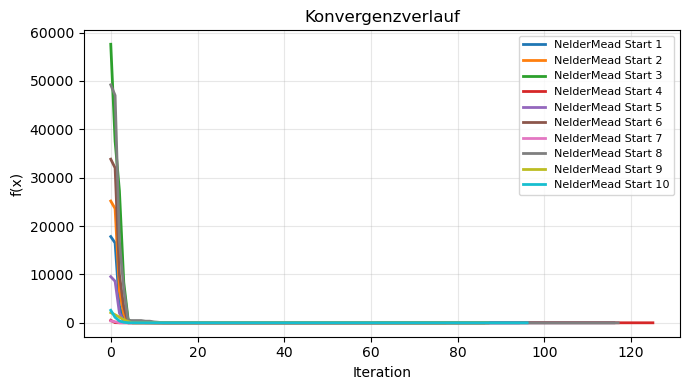

In [8]:
results.plot_convergence()

In [1]:
import optiviz
import numpy as np

def f(x):
    return (x[0] - 1)**2 + (x[1] + 2)**2 + (x[2] - 0.5)**2

bounds = [(-5, 5), (-5, 5), (-5, 5)]

result = optiviz.optimize(
    f,
    bounds,
    method="neldermead",
    x0=[4, -4, 3],
    plot=False   
)

print(result.paths)
print(result.f_paths)

[array([[ 4.        , -4.        ,  3.        ],
       [ 4.        , -3.5       ,  3.        ],
       [ 3.        , -3.5       ,  3.5       ],
       [ 3.        , -3.        ,  2.5       ],
       [ 3.        , -3.        ,  2.5       ],
       [ 0.66666667, -2.16666667,  3.        ],
       [ 0.33333333, -0.83333333,  1.5       ],
       [ 0.33333333, -0.83333333,  1.5       ],
       [ 0.33333333, -0.83333333,  1.5       ],
       [ 0.66666667, -0.75925926,  0.62962963],
       [ 0.66666667, -0.75925926,  0.62962963],
       [ 0.66666667, -0.75925926,  0.62962963],
       [ 1.66666667, -1.26817558,  0.72359396],
       [ 1.66666667, -1.26817558,  0.72359396],
       [ 0.77777778, -1.70861911,  0.7519433 ],
       [ 0.77777778, -1.70861911,  0.7519433 ],
       [ 0.77777778, -1.70861911,  0.7519433 ],
       [ 0.77777778, -1.70861911,  0.7519433 ],
       [ 0.77777778, -1.70861911,  0.7519433 ],
       [ 1.05807042, -2.33062419,  0.71504833],
       [ 1.24058832, -2.0930391 ,  0.54

In [2]:
path = result.paths[0]
values = result.f_paths[0]

print(path.shape)

(103, 3)


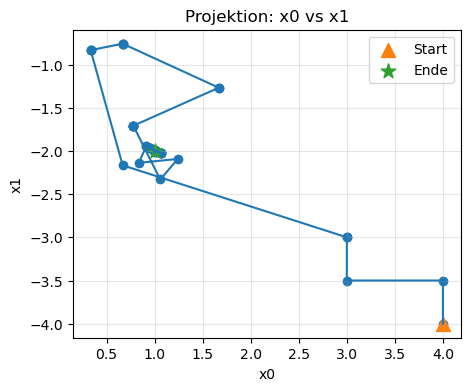

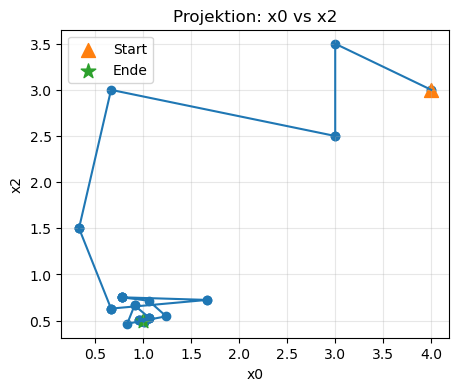

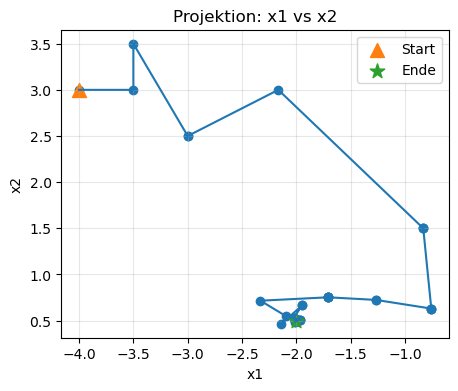

In [3]:
ndim = path.shape[1]

import itertools


pairs = list(itertools.combinations(range(ndim), 2))

for dim_i, dim_j in pairs:
    px = path[:, dim_i]
    py = path[:, dim_j]

    import matplotlib.pyplot as plt    
    
    plt.figure(figsize=(5, 4))
    plt.plot(px, py, lw=1.5)
    plt.scatter(px, py)

    plt.scatter(px[0], py[0], marker="^", s=100, label="Start")
    plt.scatter(px[-1], py[-1], marker="*", s=120, label="Ende")

    plt.xlabel(f"x{dim_i}")
    plt.ylabel(f"x{dim_j}")
    plt.title(f"Projektion: x{dim_i} vs x{dim_j}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.show()

In [9]:
result.f_optima

f([1,-2,0.5])

0.0